In [1]:
from langgraph.graph import MessagesState
# from langchain_openai import ChatOpenAI
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
# model = ChatOpenAI()

llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="conversational"
)
model = ChatHuggingFace(llm=llm)

c:\LKANTA\MY_STUDY\AgenticAI_Tutorial\lkr\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

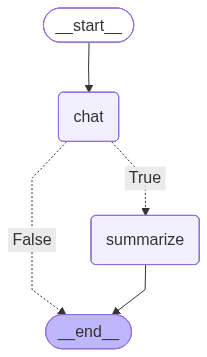

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [13]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='70fe7f9a-5b04-49e8-971a-6975d9e19571')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics, is a fundamental theory in phy


In [14]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='70fe7f9a-5b04-49e8-971a-6975d9e19571'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the physical properties of nature at the scale of atoms and subatomic particles. It is one of the most successful and well-tested theories in the history of science, providing a framework for understanding various phenomena from the smallest particles to complex systems.\n\n### Key Concepts\n\n1. **Wave-Particle Duality**: Particles like electrons and photons exhibit properties of both waves and particles. This was famously demonstrated by the double-slit experiment, which showed that particles can create interference patterns, a characteristic of waves.\n\n2. **Quantum Superposition**: A quantum system can exist in multiple states simultaneously until it is observed or measured. This principle is counterintuitive and is a fundamental aspect 

In [15]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='70fe7f9a-5b04-49e8-971a-6975d9e19571'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the physical properties of nature at the scale of atoms and subatomic particles. It is one of the most successful and well-tested theories in the history of science, providing a framework for understanding various phenomena from the smallest particles to complex systems.\n\n### Key Concepts\n\n1. **Wave-Particle Duality**: Particles like electrons and photons exhibit properties of both waves and particles. This was famously demonstrated by the double-slit experiment, which showed that particles can create interference patterns, a characteristic of waves.\n\n2. **Quantum Superposition**: A quantum system can exist in multiple states simultaneously until it is observed or measured. This principle is counterintuitive and is a fundamental aspect 

In [16]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='70fe7f9a-5b04-49e8-971a-6975d9e19571'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the physical properties of nature at the scale of atoms and subatomic particles. It is one of the most successful and well-tested theories in the history of science, providing a framework for understanding various phenomena from the smallest particles to complex systems.\n\n### Key Concepts\n\n1. **Wave-Particle Duality**: Particles like electrons and photons exhibit properties of both waves and particles. This was famously demonstrated by the double-slit experiment, which showed that particles can create interference patterns, a characteristic of waves.\n\n2. **Quantum Superposition**: A quantum system can exist in multiple states simultaneously until it is observed or measured. This principle is counterintuitive and is a fundamental aspect 